# **TP 3 : Computational Statistics**

__Abel Verley__

## **Exercice 1 :**

In [318]:
import jax 
import jax.numpy as jnp 
import jax.random as jr 
import matplotlib.pyplot as plt 

key = jr.PRNGKey(1)

### 1.A - A population model for longitudinal data

>**Question 1 :** La log-vraissemblance complète se décompose de la manière suivante : 
\begin{equation}
    \log q(y,z,\theta) = \log q(y | z, \theta) + \log q(z | \theta) + \log q(\theta) 
\end{equation} 
On s'interesse donc au calcul de chacun de ces termes, de la droite vers la gauche. Dans la suite le terme $cte$ correspond à une constante additive générique indépendante de $y$, $z$ et $\theta$. Le premier terme $\log q(\theta)$ correspond au prior : 
\begin{align}
    \log q(\theta) &= \log q(\bar t_0) +\log q(\bar v_0) + \log q( \sigma_\xi^2)+ \log q(\sigma_\tau^2) + \log q(\sigma^2) \\
                 &=  \log \mathcal{N}(\bar t_0 | \bar{\bar{t_0}}, s_{t_0}^2) +\log \mathcal{N}(\bar v_0 | \bar{\bar{v_0}}, s_{v_0}^2) + \log \mathcal{W}^{-1}(\sigma_\xi^2|v_\xi, m_\xi)+ \log \mathcal{W}^{-1}(\sigma_\tau^2|v_\tau, m_\tau) + \log \mathcal{W}^{-1}(\sigma^2|v, m) \\
                 &= - \frac{1}{2}\left(\frac{(\bar t_0 - \bar{\bar{t_0}})^2}{s_{t_0}^2}+\frac{(\bar v_0 - \bar{\bar{v_0}})^2}{s_{v_0}^2}\right)+\log(\sigma_\xi^{-m_{\xi}-2}\sigma_\tau^{-m_{\tau}-2}\sigma^{-m-2}) - \frac{v_\xi^2}{2\sigma_\xi^2}- \frac{v_\tau^2}{2\sigma_\tau^2} - \frac{v^2}{2\sigma^2} + cte
\end{align}
Le second terme se calcule de la manière suivante : 
\begin{align}
    \log q(z | \theta) &= \log q(t_0 | \theta) + \log q(v_0 | \theta) + \sum_{i =1}^N \left[ \log q(\alpha_i | \theta) + \log q(\tau_i | \theta) \right] \\
                    &= \log \mathcal{N}(t_0 | \bar t_0, \sigma_{t_0}^2) + \log \mathcal{N}(v_0 | \bar v_0, \sigma_{v_0}^2) + \sum_{i =1}^N \left[- \log \alpha_i + \log\mathcal{N}(\log \alpha_i | 0, \sigma_\xi^2 ) + \mathcal{N}(\tau_i | 0, \sigma_\tau^2) \right] \\
                    &= - \frac{1}{2}\left(\frac{(t_0-\bar t_0)^2}{\sigma_{t_0}^2}+ \frac{(v_0-\bar v_0)^2}{\sigma_{v_0}^2}\right) - \frac{1}{2}\sum_{i = 1 }^N\left[2 \log \alpha_i +\log(\sigma_\xi^2 \sigma_\tau^2 )+\frac{\log^2(\alpha_i)}{\sigma_\xi^2} + \frac{\tau_i^2}{\sigma_\tau^2} \right] + cte
\end{align}
Finalement, on a aussi : 
\begin{align}
    \log q(y | z, \theta) &= \sum_{i = 1}^N \sum_{j = 1}^{k_i}\log(q(y_{i,j}| z_{pop}, z_i, \theta)) \\ 
                        &= \sum_{i = 1}^N \sum_{j = 1}^{k_i}\log\mathcal{N}(y_{i,j}|d_i(t_{i,j}), \sigma^2) \\
                        &= -\frac{1}{2}\sum_{i = 1}^N \sum_{j = 1}^{k_i}\left[ \log(\sigma^2) + \frac{(y_{i,j}-d_i(t_{i,j}))^2}{\sigma^2}\right] +cte
\end{align}
On en déduit donc la log-vraissemblance complète du modèle : 
\begin{equation}
     \log q(y,z,\theta) = \langle S(y,z), \Psi(\theta)\rangle - \Phi(\theta)- h(y,z) + cte
\end{equation}
où les fonctions $S$, $\Phi$, $\Psi$ et $h$ sont données par : 
\begin{align}
    S(y,z) &= \left[\sum_{i = 1}^N \sum_{j = 1}^{k_i}(y_{i,j}-d_i(t_{i,j}))^2, \sum_{i = 1}^N \tau_i^2, \sum_{i = 1}^N \log^2 (\alpha_i), t_0, v_0\right]^T \\
    \Psi(\theta) &= \left[\frac{-1}{2\sigma^2}, \frac{-1}{2 \sigma_\tau^2}, \frac{-1}{2 \sigma_\xi^2}, \frac{\bar t_0}{\sigma_{t_0}^2}, \frac{\bar v_0}{\sigma_{v_0}^2}\right]^T \\
    \Phi(\theta) &= \frac{1}{2}\left(\frac{(\bar t_0 - \bar{\bar{t_0}})^2}{s_{t_0}^2}+ \frac{(\bar v_0 - \bar{\bar{v_0}})^2}{s_{v_0}^2} + \frac{\bar t_0^2}{\sigma_{t_0}^2}+\frac{\bar v_0^2}{\sigma_{v_0}^2}+\frac{v_\xi^2}{\sigma_\xi^2}+\frac{v_\tau^2}{\sigma_\tau^2}+\frac{v^2}{\sigma^2}\right)+\log(\sigma_\xi^{m_\xi+N+2}\sigma_\tau^{m_\tau+N+2}\sigma^{m+(\sum_{i = 1}^Nk_i)+2}) \\
    h(y,z) &=  \sum_{i = 1}^N \log (\alpha_i) + \frac{1}{2}\left(\frac{t_0^2}{\sigma_{t_0}^2}+\frac{v_0^2}{\sigma_{v_0}^2}\right)
\end{align}
De plus $\Phi : \mathbb{R}^5 \to \mathbb{R}^5$, il s'agit donc bien d'une famille exponentielle, en revanche elle est pleine selon la [définition de Casella et Berger](https://math.stackexchange.com/questions/383960/definitions-for-an-exponential-family-to-be-curved-or-flat).



>**Question 2 :** Le programme suivant prend génère les paramètres du modèles, les variables latentes et renvoie un échantillon de trajectoire longitudinal $y_1, \dots, y_k$. Pour échantillonner la distribution inverse Wishart, on utilise le fait que $\mathcal{W}^{-1}(v,m) = \Gamma^{-1}(\frac{m}{2}, \frac{v^2}{2})$.

In [319]:
# Initialize fixed parameters for a population longitudinal model:
p0 = 1.             
sigma2_t0 = 0.25      
sigma2_v0 = 0.25      
t0_bb = 1.0           
s2_t0 = 0.5           
v0_bb = 1.0           
s2_v0 = 0.25        
v_xi = 1.        
v_tau = 1.         
v = 1.  
m_xi = 5.     
m_tau = 5.      
m = 5.     

In [320]:
def sample_inv_wishart(key, v, m):
    alpha = m/2
    beta = v**2/2
    return beta/jr.gamma(key, alpha)

In [321]:
def sample_parameters(key):

    subkeys = jr.split(key, 5)
    t0_b = t0_bb + jnp.sqrt(s2_t0) * jr.normal(subkeys[0])
    v0_b = v0_bb + jnp.sqrt(s2_v0) * jr.normal(subkeys[1])
    sigma2_xi = sample_inv_wishart(subkeys[2], v_xi, m_xi)
    sigma2_tau = sample_inv_wishart(subkeys[3], v_tau, m_tau)
    sigma2 = sample_inv_wishart(subkeys[4], v, m)

    parameters = {
        "t0_b" : t0_b, 
        "v0_b" : v0_b, 
        "sigma2_xi" : sigma2_xi,
        "sigma2_tau" : sigma2_tau,
        "sigma2" : sigma2
    }
    
    return parameters

In [322]:
def sample_fixed_effects(key, parameters):

    subkeys = jr.split(key, 4)

    # Sample latent variables z_pop: 
    t0 = parameters["t0_b"] + jnp.sqrt(sigma2_t0) * jr.normal(subkeys[2])
    v0 = parameters["v0_b"] + jnp.sqrt(sigma2_v0) * jr.normal(subkeys[3])

    fixed_effects = {
        "t0" : t0,
        "v0" : v0
    }
    return fixed_effects

In [323]:
def sample_longitudinal_data(key, t, parameters, fixed_effects):
    """ Sample one trajectory of the longitudinal model
    """
    t0, v0 = fixed_effects["t0"], fixed_effects["v0"]
    sigma2_xi, sigma2_tau, sigma2 = parameters["sigma2_xi"], parameters["sigma2_tau"], parameters["sigma2"]

    subkeys = jr.split(key, 3)

    # Sample latent variables z: 
    alpha = jnp.exp(jnp.sqrt(sigma2_xi) * jr.normal(subkeys[0]))
    tau = jnp.sqrt(sigma2_tau) * jr.normal(subkeys[1])
    
    # Sample observations y: 
    y = jnp.sqrt(sigma2) * jr.normal(subkeys[2], shape = (len(t),)) + p0 + v0*alpha*(t-t0-tau)

    return y

In [324]:
N = 10
tt = jnp.stack([jnp.linspace(0, 10, 100) for i in range(N)])
key, subkey1, subkey2, subkey3 = jr.split(key, 4)
subkeys = jr.split(subkey1, N)

parameters = sample_parameters(subkey2)
fixed_effects = sample_fixed_effects(subkey3, parameters)
ys = jax.vmap(lambda key, t : sample_longitudinal_data(key,t,parameters, fixed_effects))(subkeys, tt)


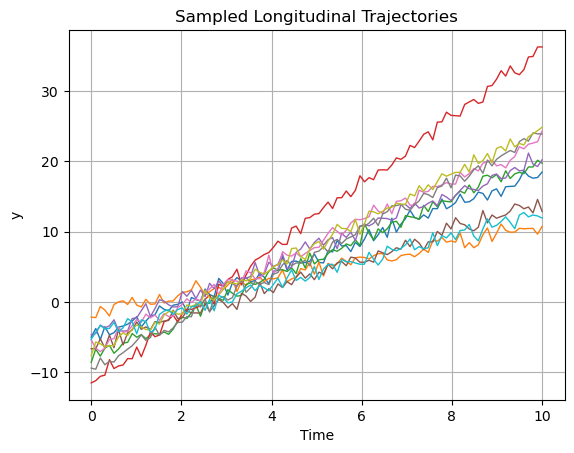

In [325]:
for i in range(tt.shape[0]):
    plt.plot(tt[i], ys[i], label=f'Trajectory {i+1}', linewidth=1)

plt.xlabel('Time')
plt.ylabel('y')
plt.title('Sampled Longitudinal Trajectories')
plt.grid()
plt.show()

### 1.B - HM-SAEM - Hasting-Metropolis sampler

>**Question 3 :** Par le théorème de Bayes, on a 
\begin{align}
    \log q(z | y, \theta) &= \log q(z| \theta) + \log q(y|z, \theta) + cte \\ 
                    &= \log \mathcal{N}(t_0 | \bar t_0, \sigma^2_{t_0})+ \log \mathcal{N}(v_0 | \bar v_0, \sigma^2_{v_0}) + \sum_{i = 1}^N\left[ \log \mathcal{N}(\xi_i|0, \sigma_\xi^2)+ \log\mathcal{N}(\tau_i|0, \sigma_\tau^2)+ \sum_{j = 1}^{k_i}\log \mathcal{N}(y_{i,j}|d_i(t_{i,j}), \sigma^2) \right] + cte  \\
                    &= -\frac{1}{2}\left[\frac{(t_0-\bar t_0)^2}{\sigma^2_{t_0}} +\frac{(v_0-\bar v_0)^2}{\sigma^2_{v_0}} +\sum_{i = 1}^N \left(\frac{\xi_i^2}{\sigma_\xi^2}+\frac{\tau_i^2}{\sigma_\tau^2} + \sum_{j = 1}^{k_i}\frac{(y_{i,j}-d_i(t_{i,j}))^2}{\sigma^2}\right)\right] + cte
\end{align}
Le terme $cte$ correspond à une constante additive générique indépendante de $z$. Comme suggéré dans l'énoncé, on utilise SRW-HM, l'alorithme de Metropolis-Hastings avec un noyau de transition gaussien $q( \cdot | z^{(k)}) = \mathcal{N}(\cdot | z^{(k)}, \Sigma) $. La probabilité d'acceptation est donnée par : 
\begin{equation}
    \alpha(z^{(k)}, z^*) = \min\left(1, \frac{q(z^*| y, \theta)}{q(z^{(k)}|y, \theta)}\right)
\end{equation}
Dans la suite de cette question on implémente l'algorithme et on le test avec le jeu de donnée synthétique et les valeurs de paramètres générées précédemment. La figure obtenue montre bien une convergence de l'algorithme.

In [326]:
def ll_post(z, ys, tt, theta):
    # Unwrap the variables
    t0, v0, xi, tau = z["t0"], z["v0"], z["xi"], z["tau"]
    t0_b, v0_b, sigma2_xi, sigma2_tau, sigma2 = theta["t0_b"], theta["v0_b"], theta["sigma2_xi"], theta["sigma2_tau"], theta["sigma2"]

    # Add terms for a posteriori log-likelihood
    ll_post = -0.5*(
        (t0-t0_b)**2/sigma2_t0 
        + (v0-v0_b)**2/sigma2_v0 
        + jnp.sum(xi**2/sigma2_xi + tau**2/sigma2_tau)
        + jnp.sum(jnp.sum((ys - p0 - v0*jnp.exp(xi[:,None])*(tt-t0-tau[:,None]))**2/sigma2, axis = 1))
        )
    
    return ll_post


In [327]:
def SRW_HM(key, z_init, ys, tt, theta, var, n_iter, *, log = False):

    # Auxiliary function to define one step of the HM algo
    def HM_step(carry, key):
        # Unwrap carry and z
        z = carry["z"]
        n_accepted = carry["n_accepted"]
        t0, v0, xi, tau = z["t0"], z["v0"], z["xi"], z["tau"]
        
        key, subkey = jr.split(key)
        subkeys = jr.split(subkey, 5)
        
        # Generate the proposal
        z_star = {
            "t0": t0+jnp.sqrt(var)*jr.normal(subkeys[0]),
            "v0": v0+jnp.sqrt(var)*jr.normal(subkeys[1]), 
            "xi": xi+jnp.sqrt(var)*jr.normal(subkeys[2], shape = (len(xi),)),
            "tau": tau+jnp.sqrt(var)*jr.normal(subkeys[3], shape = (len(tau),))
        }
        # Compute log-likelihoods
        ll_star = ll_post(z_star, ys, tt, theta)
        ll_prev = ll_post(z, ys, tt, theta)

        # Acceptance-rejection
        u = jr.uniform(subkeys[4])
        accept = jnp.log(u)<ll_star-ll_prev

        z, ll, n_accepted = jax.lax.cond(
            accept,
            lambda _: (z_star, ll_star, n_accepted+1),
            lambda _: (z, ll_prev, n_accepted),
            operand=None
        )

        # Build the output
        carry = {
            "z" : z, 
            "n_accepted" : n_accepted
            }

        return carry, ll

    # Run the HM algorithm with lax.scan 
    init = {
        "z" : z_init,
        "n_accepted" : 0
    }
    keys = jr.split(key, n_iter)
    carry, lls = jax.lax.scan(HM_step, init, keys)

    if log : 
        print(f"Metropolis Hastings runs with acceptance rate : {carry['n_accepted']/n_iter:.3f}")
    
    return carry["z"], lls, carry['n_accepted']

In [328]:
# Define some dummy arguments for SRW_HM
z_init = {
    "t0": 0.0,
    "v0": 0.0,
    "xi": jnp.zeros((N,)),
    "tau": jnp.zeros((N,))
}
var = 0.01
n_iter = 1000

key, subkey = jr.split(key)
z, lls,_ = SRW_HM(subkey, z_init, ys, tt, parameters, var, n_iter, log = True)


Metropolis Hastings runs with acceptance rate : 0.071


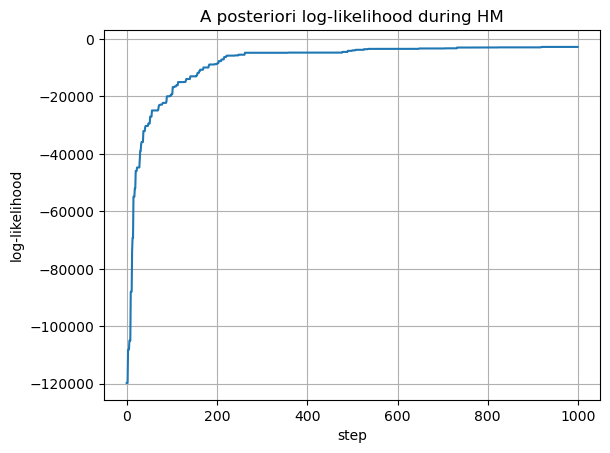

In [329]:
plt.plot(lls)
plt.title("A posteriori log-likelihood during HM")
plt.xlabel("step")
plt.ylabel("log-likelihood")
plt.grid()

>**Question 4 :** On cherche à résoudre le problème d'optimisation suivant : 
\begin{equation}
    \theta^* \in \arg \max_{\theta \in \Theta}\left( -\Phi(\theta) + \langle S, \Psi (\theta) \rangle\right)
\end{equation}
On note $J$ la fonction à maximiser, on calcule alors le gradient de $J$ : 
\begin{equation}
    \nabla J(\theta) = - \nabla \Phi(\theta) + \sum_{i = 1}^d S_i \nabla \Psi_i(\theta)
\end{equation} 
avec le gradient suivant pour $\Phi$ 
\begin{equation}
    \nabla \Phi(\theta) = \left[\frac{\bar t_0- \bar{\bar{t_0}}}{s_{t_0}^2} + \frac{\bar t_0}{\sigma_{t_0}^2}, \frac{\bar v_0- \bar{\bar{v_0}}}{s_{v_0}^2} + \frac{\bar v_0}{\sigma_{v_0}^2}, -\frac{v_\xi^2}{2\sigma_\xi^4} + \frac{m_\xi +N + 2}{2\sigma_\xi^2},-\frac{v_\tau^2}{2\sigma_\tau^4} + \frac{m_\tau +N+2}{2\sigma_\tau^2},-\frac{v^2}{2\sigma^4} + \frac{m +\sum_{i = 1}^N k_i+2}{2\sigma_\xi^2}\right]^T
\end{equation}
et la jacobienne de $\Psi$: 
\begin{equation}
    J \Psi(\theta)=
    \begin{pmatrix}
        0 & 0 & 0 & 0 & \frac{1}{2\sigma^4} \\
        0 & 0 & 0 & \frac{1}{2\sigma_\tau^4} & 0 \\
        0 & 0 & \frac{1}{2\sigma_\xi^4} & 0 & 0 \\
        \frac{1}{\sigma^2_{t_0}} & 0 & 0 & 0 & 0 \\
        0 & \frac{1}{\sigma^2_{v_0}} & 0 & 0 & 0 
    \end{pmatrix}
\end{equation}
On trouve donc que l'annulation du gradient de $J$ équivaut aux conditions suivante, qui donnes les règles de mise à jour dans l'algorithme EM : 
\begin{align}
    \bar t_0 &= \frac{S_4s_{t_0}^2 + \bar{\bar{t_0}}\sigma_{t_0}^2}{s_{t_0}^2 + \sigma_{t_0}^2} \\
    \bar v_0 &= \frac{S_5s_{v_0}^2 + \bar{\bar{v_0}}\sigma_{v_0}^2}{s_{v_0}^2 + \sigma_{v_0}^2} \\
    \sigma_\xi^2 &= \frac{v_\xi^2+S_3}{m_\xi + N + 2} \\
    \sigma_\tau^2 &= \frac{v_\tau^2+S_2}{m_\xi + N + 2} \\
    \sigma^2 &= \frac{v^2+S_1}{m + \sum_{i=1}^Nk_i + 2} \\
\end{align} 
Dans la suite de cette question, on se sert de cette expression de la solution du problème d'optimisation pour implémenter l'algorithme HM-SAEM. On obtient, des valeurs raisonablement proches de la ground truth, en revanche, il faut choisir une variance très faible pour avoir un taux d'acceptation raisonnable dans la méthode d'échantillonnage. 

In [330]:
def HM_SAEM(key, ys, tt, theta0, n_iter, Nb, alpha, *, sampler_var = 0.01, sampler_iter = 1000):
    # Initialization
    N = ys.shape[0]
    K = ys.shape[1]
    z_init = {
        "t0": 0.0,
        "v0": 0.0,
        "xi": jnp.zeros((N,)),
        "tau": jnp.zeros((N,))
    }
    S_init = jnp.zeros(5)

    # Auxiliary function for HM-SAEM step 
    def HM_SAEM_step(carry, key):
        # Unwrap the carry and z
        z_old, S, theta, k = carry["z"], carry["S"],carry["theta"],  carry["k"]
        
        # Simulation
        z,_,n_accepted = SRW_HM(key, z_old, ys, tt, theta, sampler_var, sampler_iter)
        t0, v0, xi, tau = z["t0"], z["v0"], z["xi"], z["tau"]


        # Compute step-size
        eps = jax.lax.cond(
            k > Nb,
            lambda: (k-Nb)**(-alpha),
            lambda: 1.0
        )

        # Stochastic approximation 
        Syz = jnp.array([
            jnp.sum(jnp.sum((ys - p0 - v0*jnp.exp(xi[:,None])*(tt-t0-tau[:,None]))**2, axis = 1)), 
            jnp.sum(tau**2),
            jnp.sum(xi**2), 
            t0, 
            v0
        ])
        S += eps*(Syz-S)

        # Maximization
        theta = {
            "t0_b" : (S[3]*s2_t0+ t0_bb*sigma2_t0)/(s2_t0+sigma2_t0),
            "v0_b" : (S[4]*s2_v0+ v0_bb*sigma2_v0)/(s2_v0+sigma2_v0),
            "sigma2_xi" : (v_xi**2 + S[2])/(m_xi + N + 2), 
            "sigma2_tau" : (v_tau**2 + S[1])/(m_tau + N + 2),
            "sigma2" : (v**2 + S[0])/(m + N*K + 2),  
        } 
 

        # output results  
        carry = {
            "z" : z,
            "S" : S,
            "theta" : theta, 
            "k" : k+1
        }
        
        return carry, {"theta" : theta, "z" : z, "n_accepted" : n_accepted }
    
    # Run the HM-SAEM algo with jax.lax.scan
    init = {
        "z" : z_init, 
        "S" : S_init,
        "theta" : theta0, 
        "k" : 0
        }
    keys = jr.split(key, n_iter)
    carry, results = jax.lax.scan(HM_SAEM_step, init, keys)

    return carry["theta"], results["theta"], results["z"], results["n_accepted"]

In [331]:
theta_init = {
    "t0_b": 1.,    
    "v0_b": 1.0,   
    "sigma2_xi": 0.5, 
    "sigma2_tau": 0.5,
    "sigma2": 0.5
}


n_iter = 5000
Nb = 500 
alpha = 0.9
sampler_var = 0.000025
sampler_iter = 1000
key, subkey = jr.split(key)
theta_est, param_ev, zs, n_accepteds = HM_SAEM(subkey, ys, tt, theta_init, n_iter, Nb, alpha, sampler_var = sampler_var, sampler_iter = sampler_iter)

########## sigma2 ########## 

Estimated value : 0.4570898711681366
Ground truth : 0.46050775051116943
Relative error : 0.74% 

########## sigma2_tau ########## 

Estimated value : 0.18621569871902466
Ground truth : 0.18233199417591095
Relative error : 2.13% 

########## sigma2_xi ########## 

Estimated value : 0.142005056142807
Ground truth : 0.14024755358695984
Relative error : 1.25% 

########## t0_b ########## 

Estimated value : 2.152662515640259
Ground truth : 2.1480674743652344
Relative error : 0.21% 

########## v0_b ########## 

Estimated value : 1.672987699508667
Ground truth : 1.781848669052124
Relative error : 6.11% 



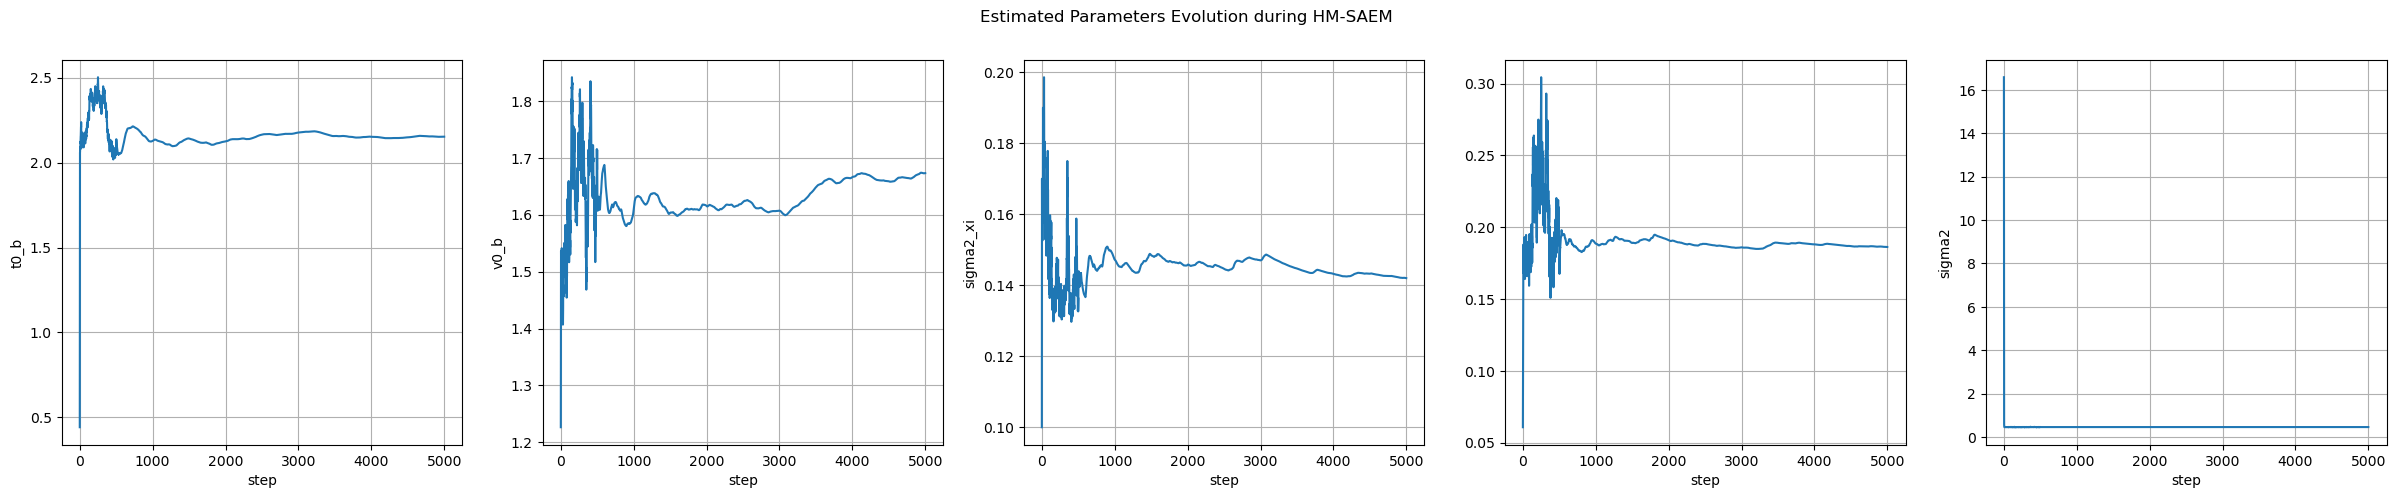

In [332]:
for k in theta_est: 
    print(f"########## {k} ########## \n")
    print(f"Estimated value : {theta_est[k]}")
    print(f"Ground truth : {parameters[k]}")
    print(f"Relative error : {jnp.abs(100*(theta_est[k]-parameters[k])/parameters[k]):.2f}% \n")

fig, ax = plt.subplots(1, 5, figsize = (30, 5))
ax[0].plot(param_ev["t0_b"])
ax[0].set_xlabel("step")
ax[0].set_ylabel("t0_b")
ax[0].grid()
ax[1].plot(param_ev["v0_b"])
ax[1].set_xlabel("step")
ax[1].set_ylabel("v0_b")
ax[1].grid()
ax[2].plot(param_ev["sigma2_xi"])
ax[2].set_xlabel("step")
ax[2].set_ylabel("sigma2_xi")
ax[2].grid()
ax[3].plot(param_ev["sigma2_tau"])
ax[3].set_xlabel("step")
ax[3].grid()
ax[4].plot(param_ev["sigma2"])
ax[4].set_xlabel("step")
ax[4].set_ylabel("sigma2")
ax[4].grid()

fig.suptitle("Estimated Parameters Evolution during HM-SAEM")
plt.show()


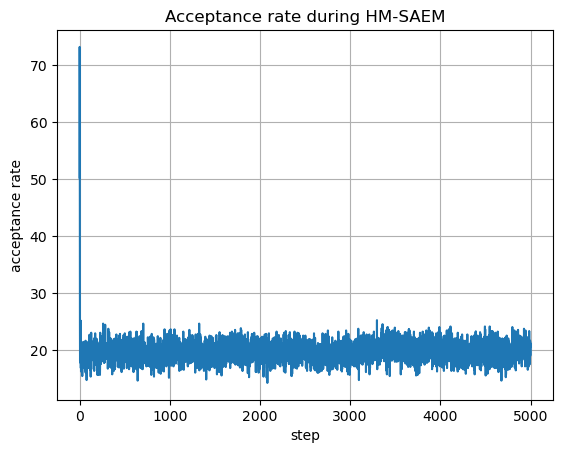

In [333]:
plt.plot(100*n_accepteds/sampler_iter)
plt.xlabel("step")
plt.ylabel("acceptance rate")
plt.title("Acceptance rate during HM-SAEM")
plt.grid()
plt.show()

### 1.C HMwG-SAEM - Hasting-Metropolis within Gibbs sampler

>**Question 5 :** Pour échantillonner $z_i$ avec la distribition $q(z_i | z_{pop}, \theta, y)$, on utilise l'échantillonnage de Gibbs. Pour $z_i^{(k)}$ fixé, on échantillonne $z_{i}^{(k+1)}$ de la manière suivante : 
\begin{equation}
    \begin{cases}
        \xi_i^{(k+1)} \sim q(\cdot | z_{pop}, \tau_i^{(k)}, \theta, y) \\
        \tau_i^{(k+1)} \sim q(\cdot | z_{pop}, \xi_i^{(k+1)}, \theta, y) \\
    \end{cases}
\end{equation}
où $\xi_i^{k+1}$ et $\tau_i^{k+1}$ échantillonné par SRW-HM. En particulier, les distributions cibles de SRW-HM sont données par : 
\begin{align}
    \log q(\xi_i | z_{pop}, \tau_i, \theta, y) &= \log q(\xi_i | z_{pop}, \tau_i, \theta, y_i) \\
                                            &=  \log q(y_i | z, \theta) + \log q(\xi_i | z_{pop}, \tau_i, \theta) + cte \\
                                            &= \sum_{j= 1}^{k_i}\log \mathcal{N}(y_{i,j} | d_i(t_{i,j}), \sigma^2)+ \log \mathcal{N}(\xi_i | \sigma_\xi^2) + cte \\ 
                                            &= -\sum_{j= 1}^{k_i}\frac{(y_{i,j}-d_i(t_{i,j}))^2}{2\sigma^2} - \frac{\xi_i^2}{2\sigma_\xi^2} + cte 
\end{align}
et de même, 
\begin{equation}
    \log q(\tau_i | z_{pop}, \xi_i, \theta, y)=-\sum_{j= 1}^{k_i}\frac{(y_{i,j}-d_i(t_{i,j}))^2}{2\sigma^2} - \frac{\tau_i^2}{2\sigma_\tau^2} + cte 
\end{equation}
Dans la suite on implémente, SRW-HM pour échantillonner respectivement $\xi_i^{k+1}$ et $\tau_i^{k+1}$, ainsi que la méthode de Gibbs pour générer $z_i$. 

Implémentation des échantillonneurs pour $\xi_i$ et $\tau_i$ :

In [334]:
# log a posteriori for xi
def ll_xi(xi, z_pop, tau, theta, y, t):
    t0, v0 = z_pop["t0"], z_pop["v0"]
    sigma2_xi, sigma2 = theta["sigma2_xi"], theta["sigma2"]
    return -jnp.sum((y - p0 - v0*jnp.exp(xi)*(t - t0 - tau))**2)/(2*sigma2) - xi**2/(2*sigma2_xi)

In [335]:
# log a posteriori for tau
def ll_tau(tau, z_pop, xi, theta, y, t):
    t0, v0 = z_pop["t0"], z_pop["v0"]
    sigma2_tau, sigma2 = theta["sigma2_tau"], theta["sigma2"]
    return -jnp.sum((y - p0 - v0*jnp.exp(xi)*(t - t0 - tau))**2)/(2*sigma2) - tau**2/(2*sigma2_tau)

In [336]:
# MH sampler for xi
def SRW_HM_xi(key, xi_init, z_pop, tau, theta, y, t, var, n_iter):
    
    # Auxiliary function for HM step
    def HM_step(carry, key):
        key1, key2 = jr.split(key)

        #unwrap carry : 
        xi, n_accepted = carry["xi"], carry["n_accepted"]

        # sample proposal 
        xi_new = xi + jnp.sqrt(var)*jr.normal(key1)

        # accept-reject
        u = jr.uniform(key2)
        ll = ll_xi(xi, z_pop, tau, theta, y, t)
        ll_new = ll_xi(xi_new, z_pop, tau, theta, y, t)
        accept = jnp.log(u) <= ll_new-ll
        xi, ll, n_accepted = jax.lax.cond(
            accept,
            lambda _: (xi_new, ll_new, n_accepted+1),
            lambda _: (xi, ll, n_accepted),
            operand=None
        )

        # Return results
        carry = {
            "xi" : xi,
            "n_accepted" : n_accepted
        }
        return carry, ll
    
    # Run the MH algorithm wih jax.lax.scan
    init = {
        "xi" : xi_init,
        "n_accepted" : 0
    }
    keys = jr.split(key, n_iter)
    carry, lls = jax.lax.scan(HM_step, init, keys)
    
    return carry["xi"], lls, carry["n_accepted"]

In [337]:
# MH sampler for tau
def SRW_HM_tau(key, tau_init, z_pop, xi, theta, y, t, var, n_iter):
    
    # Auxiliary function for HM step
    def HM_step(carry, key):
        key1, key2 = jr.split(key)

        #unwrap carry : 
        tau, n_accepted = carry["tau"], carry["n_accepted"]

        # sample proposal 
        tau_new = tau + jnp.sqrt(var)*jr.normal(key1)

        # accept-reject
        u = jr.uniform(key2)
        ll = ll_tau(tau, z_pop, xi, theta, y, t)
        ll_new = ll_tau(tau_new, z_pop, xi, theta, y, t)
        accept = jnp.log(u) <= ll_new-ll
        tau, ll, n_accepted = jax.lax.cond(
            accept,
            lambda _: (tau_new, ll_new, n_accepted+1),
            lambda _: (tau, ll, n_accepted),
            operand=None
        )

        # Return results
        carry = {
            "tau" : tau,
            "n_accepted" : n_accepted
        }
        return carry, ll
    
    # Run the MH algorithm wih jax.lax.scan
    init = {
        "tau" : tau_init,
        "n_accepted" : 0
    }
    keys = jr.split(key, n_iter)
    carry, lls = jax.lax.scan(HM_step, init, keys)
    
    return carry["tau"], lls, carry["n_accepted"]

Test des échantillonneurs pour $\xi$ et $\tau$ : on parvient à obtenir un tau d'acceptation proche de 30% et la convergence des fonctions de log-vraissemblance. 

SRW-HM completed generation of xi with acceptance rate : 37.200001%
SRW-HM completed generation of tau with acceptance rate : 30.000000%


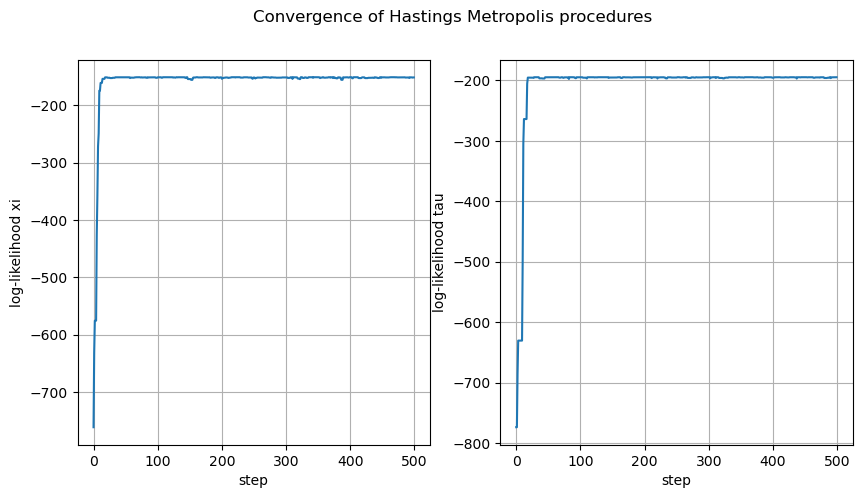

In [338]:
# Test the SRW_MH_xi and SRW_MH_tau samplers

xi_init = 1.
tau = 1.
tau_init = 1.
xi = 1.
z_pop = {
    "t0":1.,
    "v0":1.
} 
theta = parameters
y = ys[0,:]     
t = tt[0,:]
var_xi = 0.001
var_tau = 0.01
n_iter = 500

subkey1, subkey2 = jr.split(key)
xi_final, lls_xi, n_acc_xi = SRW_HM_xi(subkey1, xi_init, z_pop, tau, theta, y, t, var_xi, n_iter)
print(f"SRW-HM completed generation of xi with acceptance rate : {100* n_acc_xi/n_iter:2f}%")

tau_final, lls_tau, n_acc_tau = SRW_HM_tau(subkey2, tau_init, z_pop, xi, theta, y, t, var_tau, n_iter)
print(f"SRW-HM completed generation of tau with acceptance rate : {100* n_acc_tau/n_iter:2f}%")


fig,ax = plt.subplots(1,2, figsize = (10, 5))
ax[0].plot(lls_xi)
ax[0].set_xlabel("step")
ax[0].set_ylabel("log-likelihood xi")
ax[0].grid()
ax[1].plot(lls_tau)
ax[1].set_xlabel("step")
ax[1].set_ylabel("log-likelihood tau")
ax[1].grid()
fig.suptitle("Convergence of Hastings Metropolis procedures")
plt.show()

Implémentation de la méthode HMwGibbs : 

In [339]:
def HMwGibbs_zi(key, zi_init, z_pop, y, theta, t, n_iter, *, var_xi, var_tau, HM_iter):
    # Auxiliary function for one step of HMwGibbs
    def HMwGibbs_step(carry, key):     
        # Unwrap carry 
        xi = carry["xi"]
        tau = carry["tau"]

        subkey1, subkey2 = jr.split(key)

        # Sample new xi and tau
        # MH is initialized at current value
        xi,_, n_acc_xi = SRW_HM_xi(subkey1, xi, z_pop, tau, theta, y, t, var_xi, HM_iter)
        tau, _, n_acc_tau = SRW_HM_tau(subkey2, tau, z_pop, xi, theta, y, t, var_tau, HM_iter)

        # Output the results
        carry = {
            "xi": xi,
            "tau": tau
        }
        results = {
            "xi": xi,
            "tau" : tau,
            "n_acc_xi" : n_acc_xi,
            "n_acc_tau" : n_acc_tau
        }
        return carry, results
    
    # Run HMwGibbs with jax.lax.scan
    keys = jr.split(key, n_iter)
    zi, results = jax.lax.scan(HMwGibbs_step, zi_init, keys)
    zs = {
        "xi" : results["xi"],
        "tau": results["tau"]
    }
    n_accs = {
        "xi" : results["n_acc_xi"]/HM_iter,
        "tau" : results["n_acc_tau"]/HM_iter
    }
    return zi, zs, n_accs

Test de la méthode HMwGibbs : malgé une forte variance, les valeurs de $z_i$ semblent converger et on maintient au tau d'acceptation d'environ 30% tout au long de l'algorithme.

In [340]:
# Testing the HMwGibbs_zi
zi_init = {
    "xi" : 1.,
    "tau": 1.
}
z_pop = {
    "t0":1.,
    "v0":1.
} 
y = ys[0,:]
theta = parameters 
t = tt[0,:]
n_iter = 1000
var_xi = 0.001
var_tau = 0.01
HM_iter = 500

key, subkey = jr.split(key)

zi, zs, n_acc = HMwGibbs_zi(key, zi_init, z_pop, y, theta, t, n_iter, var_xi = var_xi, var_tau = var_tau, HM_iter = HM_iter)

Text(0.5, 0.98, 'Evolution of zi during HMwGibbs')

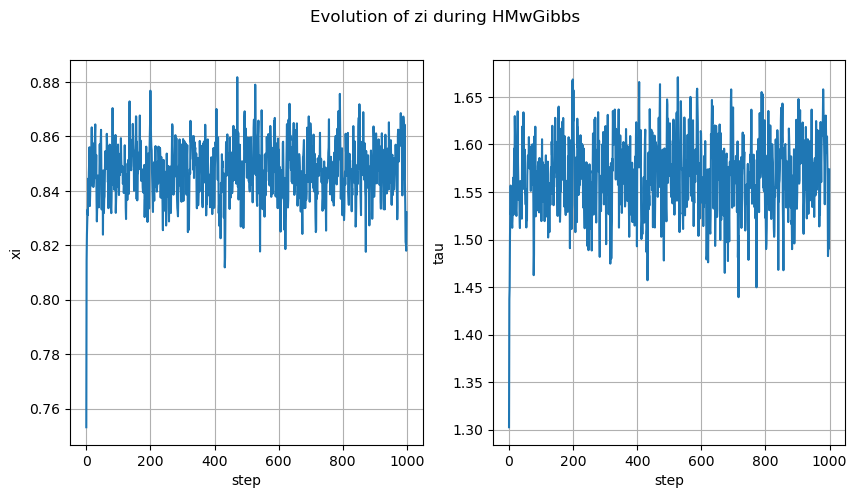

In [341]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
ax[0].plot(zs["xi"])
ax[0].set_xlabel("step")
ax[0].set_ylabel("xi")
ax[0].grid()
ax[1].plot(zs["tau"])
ax[1].set_xlabel("step")
ax[1].set_ylabel("tau")
ax[1].grid()
fig.suptitle("Evolution of zi during HMwGibbs")

Text(0.5, 0.98, 'acceptance rates of HM during HMwGibbs')

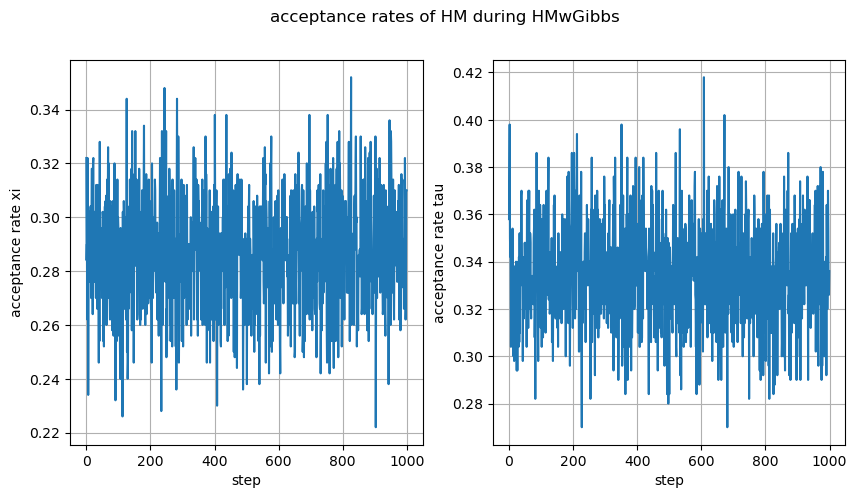

In [342]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
ax[0].plot(n_acc["xi"])
ax[0].set_xlabel("step")
ax[0].set_ylabel("acceptance rate xi")
ax[0].grid()
ax[1].plot(n_acc["tau"])
ax[1].set_xlabel("step")
ax[1].set_ylabel("acceptance rate tau")
ax[1].grid()
fig.suptitle("acceptance rates of HM during HMwGibbs")

>**Question 6 :** On procède de même que dans la question précédente, pour $z_{pop}^{(k)}$ fixé, on échantillonne $z_{pop}^{(k+1)}$ de la manière suivante : 
\begin{equation}
    \begin{cases}
        t_0^{(k+1)} \sim q(\cdot | (z_i)_{i = 1 \dots N}, v_0^{(k)}, \theta, y) \\
        v_0^{(k+1)} \sim q(\cdot | (z_i)_{i = 1 \dots N}, t_0^{(k+1)}, \theta, y) \\
    \end{cases}
\end{equation}
et les distributions cibles sont données par : 
\begin{equation}
    \log q(t_0 | (z_i)_{i = 1 \dots N}, v_0, \theta, y) = - \sum_{i = 1}^N\sum_{j = 1}^{k_i} \frac{(y_{i,j}-d_i(t_{i,j}))^2}{2 \sigma^2} - \frac{(t_0- \bar t_0)^2}{2 \sigma_{t_0}^2} +cte
\end{equation}
et de même, 
\begin{equation}
    \log q(v_0 | (z_i)_{i = 1 \dots N}, t_0, \theta, y) = - \sum_{i = 1}^N\sum_{j = 1}^{k_i} \frac{(y_{i,j}-d_i(t_{i,j}))^2}{2 \sigma^2} - \frac{(v_0- \bar v_0)^2}{2 \sigma_{v_0}^2} +cte
\end{equation}
Dans la suite de cette question on implémente l'échantillonneur de Gibbs en suivant les mêmes étapes que dans la partie précédente : 

Implémentation des échantillonneurs pour $t_0$ et $v_0$ :

In [343]:
# log a posteriori for xi
def ll_t0(t0, zs, v0, theta, ys, tt):
    xi, tau = zs["xi"], zs["tau"]
    t0_b, sigma2 = theta["t0_b"], theta["sigma2"]
    return -jnp.sum(jnp.sum((ys - p0 - v0*jnp.exp(xi[:,None])*(tt-t0-tau[:,None]))**2, axis = 1))/(2*sigma2) - (t0-t0_b)**2/(2*sigma2_t0)

In [344]:
# log a posteriori for xi
def ll_v0(v0, zs, t0, theta, ys, tt):
    xi, tau = zs["xi"], zs["tau"]
    v0_b, sigma2 = theta["v0_b"], theta["sigma2"]
    return -jnp.sum(jnp.sum((ys - p0 - v0*jnp.exp(xi[:,None])*(tt-t0-tau[:,None]))**2, axis = 1))/(2*sigma2) - (t0-v0_b)**2/(2*sigma2_v0)

In [345]:
# MH sampler for t0
def SRW_HM_t0(key, t0_init, zs, v0, theta, ys, tt, var, n_iter):
    
    # Auxiliary function for HM step
    def HM_step(carry, key):
        key1, key2 = jr.split(key)

        #unwrap carry : 
        t0, n_accepted = carry["t0"], carry["n_accepted"]

        # sample proposal 
        t0_new = t0 + jnp.sqrt(var)*jr.normal(key1)

        # accept-reject
        u = jr.uniform(key2)
        ll = ll_t0(t0, zs, v0, theta, ys, tt)
        ll_new = ll_t0(t0_new, zs, v0, theta, ys, tt)
        accept = jnp.log(u) <= ll_new-ll
        t0, ll, n_accepted = jax.lax.cond(
            accept,
            lambda _: (t0_new, ll_new, n_accepted+1),
            lambda _: (t0, ll, n_accepted),
            operand=None
        )

        # Return results
        carry = {
            "t0" : t0,
            "n_accepted" : n_accepted
        }
        return carry, ll
    
    # Run the MH algorithm wih jax.lax.scan
    init = {
        "t0" : t0_init,
        "n_accepted" : 0
    }
    keys = jr.split(key, n_iter)
    carry, lls = jax.lax.scan(HM_step, init, keys)
    
    return carry["t0"], lls, carry["n_accepted"]

In [346]:
# MH sampler for v0
def SRW_HM_v0(key, v0_init, zs, t0, theta, ys, tt, var, n_iter):
    
    # Auxiliary function for HM step
    def HM_step(carry, key):
        key1, key2 = jr.split(key)

        #unwrap carry : 
        v0, n_accepted = carry["v0"], carry["n_accepted"]

        # sample proposal 
        v0_new = v0 + jnp.sqrt(var)*jr.normal(key1)

        # accept-reject
        u = jr.uniform(key2)
        ll = ll_t0(v0, zs, t0, theta, ys, tt)
        ll_new = ll_t0(v0_new, zs, t0, theta, ys, tt)
        accept = jnp.log(u) <= ll_new-ll
        v0, ll, n_accepted = jax.lax.cond(
            accept,
            lambda _: (v0_new, ll_new, n_accepted+1),
            lambda _: (v0, ll, n_accepted),
            operand=None
        )

        # Return results
        carry = {
            "v0" : v0,
            "n_accepted" : n_accepted
        }
        return carry, ll
    
    # Run the MH algorithm wih jax.lax.scan
    init = {
        "v0" : v0_init,
        "n_accepted" : 0
    }
    keys = jr.split(key, n_iter)
    carry, lls = jax.lax.scan(HM_step, init, keys)
    
    return carry["v0"], lls, carry["n_accepted"]

Test des échantillonneurs pour $t_0$ et $v_0$ : on parvient à obtenir un tau d'acceptation entre 20% et 30% et la convergence des fonctions de log-vraissemblance. 

SRW-HM completed generation of t0 with acceptance rate : 29.400000%
SRW-HM completed generation of v0 with acceptance rate : 29.799999%


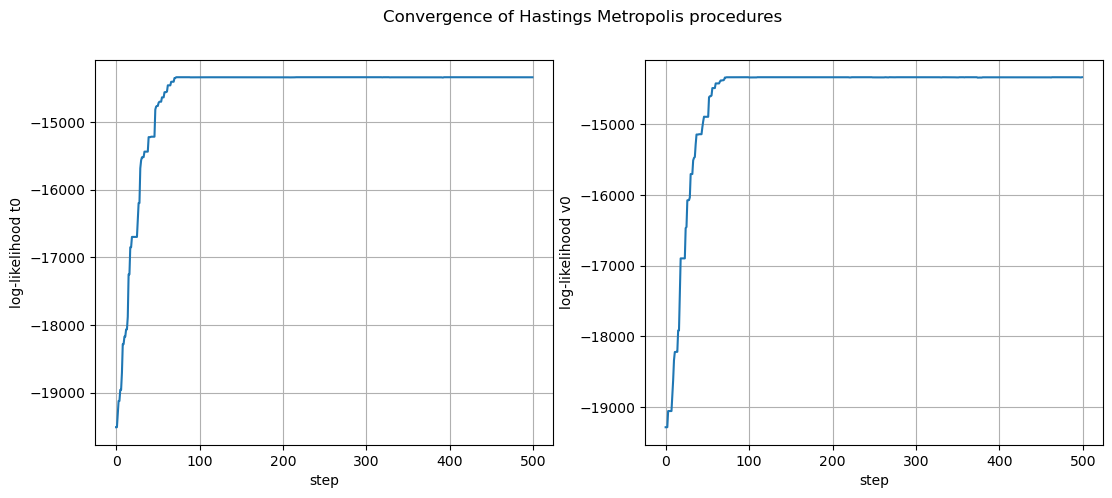

In [347]:
# Test the SRW_MH_t0 and SRW_MH_v0 samplers

t0_init = 1.
v0 = 1.
v0_init = 1.
t0 = 1.
zs = {
    "xi" : jnp.ones(N),
    "tau" : jnp.ones(N) 
}
theta = parameters
var_t0 = 0.001
var_v0 = 0.001
n_iter = 500

subkey1, subkey2 = jr.split(key)
t0_final, lls_t0, n_acc_t0 = SRW_HM_t0(subkey1, t0_init, zs, v0, theta, ys, tt, var_t0, n_iter)
print(f"SRW-HM completed generation of t0 with acceptance rate : {100* n_acc_t0/n_iter:2f}%")

v0_final, lls_v0, n_acc_v0 = SRW_HM_v0(subkey2, v0_init, zs, t0, theta, ys, tt, var_v0, n_iter)
print(f"SRW-HM completed generation of v0 with acceptance rate : {100* n_acc_v0/n_iter:2f}%")


fig,ax = plt.subplots(1,2, figsize = (13, 5))
ax[0].plot(lls_t0)
ax[0].set_xlabel("step")
ax[0].set_ylabel("log-likelihood t0")
ax[0].grid()
ax[1].plot(lls_v0)
ax[1].set_xlabel("step")
ax[1].set_ylabel("log-likelihood v0")
ax[1].grid()
fig.suptitle("Convergence of Hastings Metropolis procedures")
plt.show()

Implémentation de la méthode HMwGibbs :

In [348]:
def HMwGibbs_z_pop(key, z_pop_init, zs, ys, theta, tt, n_iter, *, var_t0, var_v0, HM_iter):
    # Auxiliary function for one step of HMwGibbs
    def HMwGibbs_step(carry, key):     
        # Unwrap carry 
        t0 = carry["t0"]
        v0 = carry["v0"]

        subkey1, subkey2 = jr.split(key)

        # Sample new xi and tau
        # MH is initialized at current value
        t0,_, n_acc_t0 = SRW_HM_t0(subkey1, t0, zs, v0, theta, ys, tt, var_t0, n_iter)
        v0, _, n_acc_v0 = SRW_HM_v0(subkey2, v0, zs, t0, theta, ys, tt, var_v0, n_iter)

        # Output the results
        carry = {
            "t0": t0,
            "v0": v0
        }
        results = {
            "t0": t0,
            "v0" : v0,
            "n_acc_t0" : n_acc_t0,
            "n_acc_v0" : n_acc_v0
        }
        return carry, results
    
    # Run HMwGibbs with jax.lax.scan
    keys = jr.split(key, n_iter)
    z_pop, results = jax.lax.scan(HMwGibbs_step, z_pop_init, keys)
    z_pops = {
        "t0" : results["t0"],
        "v0": results["v0"]
    }
    n_accs = {
        "t0" : results["n_acc_t0"]/HM_iter,
        "v0" : results["n_acc_v0"]/HM_iter
    }
    return z_pop, z_pops, n_accs

Test de la méthode HMwGibbs : les valeurs de $z_{pop}$ semblent converger et on maintient au tau d'acceptation entre 20% et 30% tout au long de l'algorithme.

In [349]:
# Testing the HMwGibbs_z_pop
z_pop_init = {
    "t0" : 1., 
    "v0" : 1.
}
zs = {
    "xi" : jnp.ones(N),
    "tau" : jnp.ones(N) 
}
theta = parameters
n_iter = 500
var_t0 = 0.0001
var_v0 = 0.0001
HM_iter = 500


key, subkey = jr.split(key)
z_pop, z_pops, n_acc = HMwGibbs_z_pop(subkey, z_pop_init, zs, ys, theta, tt, n_iter, var_t0 = var_t0, var_v0 = var_v0, HM_iter = HM_iter)

Text(0.5, 0.98, 'Evolution of z_pop during HMwGibbs')

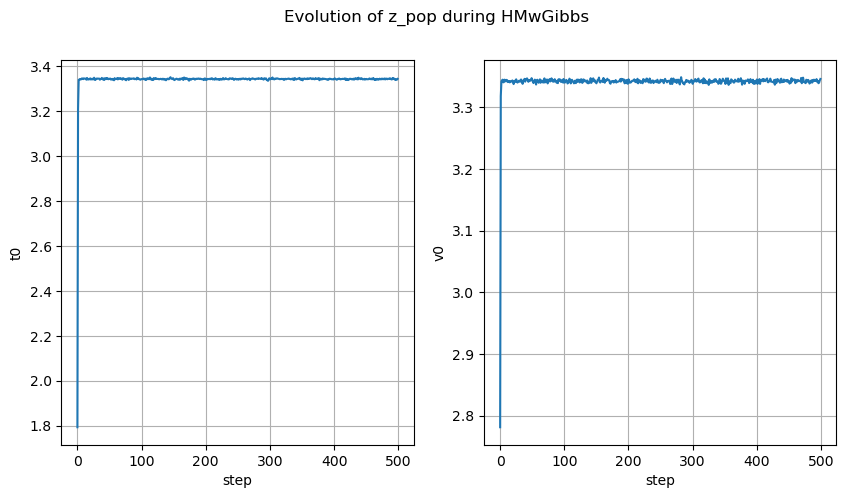

In [350]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
ax[0].plot(z_pops["t0"])
ax[0].set_xlabel("step")
ax[0].set_ylabel("t0")
ax[0].grid()
ax[1].plot(z_pops["v0"])
ax[1].set_xlabel("step")
ax[1].set_ylabel("v0")
ax[1].grid()
fig.suptitle("Evolution of z_pop during HMwGibbs")

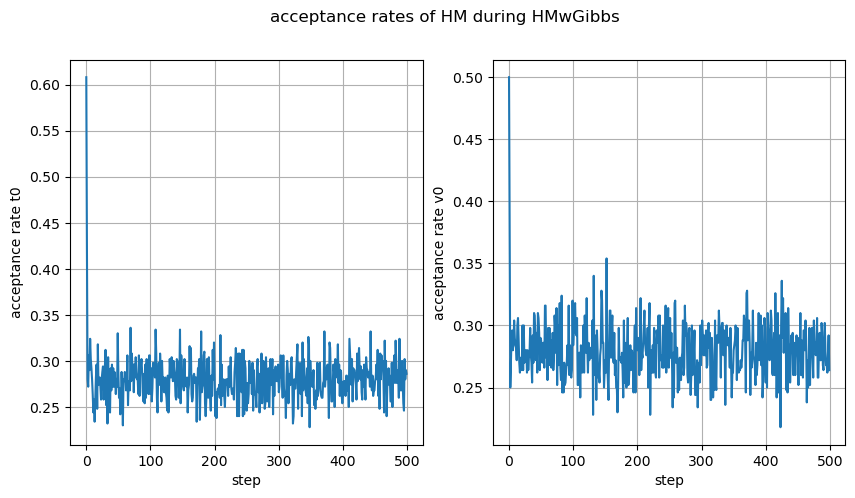

In [351]:
fig, ax = plt.subplots(1, 2, figsize = (10,5))
ax[0].plot(n_acc["t0"])
ax[0].set_xlabel("step")
ax[0].set_ylabel("acceptance rate t0")
ax[0].grid()
ax[1].plot(n_acc["v0"])
ax[1].set_xlabel("step")
ax[1].set_ylabel("acceptance rate v0")
ax[1].grid()
fig.suptitle("acceptance rates of HM during HMwGibbs")
plt.show()

>**Question 7 :** Pour obtenir l'estimateur de MAP par la méthode HMwG-SAEM, on reprend l'algorithme de la question 4 où il suffit de modifier la méthode d'échantillonnage de $z$. Pour échantillonner $z$, on utilise les méthode HMwG des questions précédentes :  
\begin{equation}
    \begin{cases}
        z_1 \sim q(\cdot | z_{pop}, y_1, \theta) \\
        \vdots \\
        z_N \sim q(\cdot | z_{pop}^{(k)}, y_N, \theta) \\
        z_{pop} \sim q(\cdot | (z_i)_{i=1, \dots N}, y, \theta) \\
    \end{cases}
\end{equation}


In [352]:
def HMwG_SAEM(key, ys, tt, theta0, n_iter, Nb, alpha, *, HMwG_iter, HM_iter, vars):
    # Initialization
    N = ys.shape[0]
    K = ys.shape[1]
    z_init = {
        "t0": 0.0,
        "v0": 0.0,
        "xi": jnp.zeros((N,)),
        "tau": jnp.zeros((N,))
    }
    S_init = jnp.zeros(5)

    # Auxiliary function for HM-SAEM step 
    def HM_SAEM_step(carry, key):
        # Unwrap the carry and z
        z_old, S, theta, k = carry["z"], carry["S"],carry["theta"],  carry["k"]
        
        # Simulation
        ################################
        ##### ONLY THIS IS CHANGED #####  (and input and output)
        ################################
        subkey1, subkey2 = jr.split(key)
        keys = jr.split(subkey1, N)
        
        # Decouple z_old : 
        zs_old = {"xi" : z_old["xi"], "tau" : z_old["tau"]}
        z_pop_old = {"t0" : z_old["t0"], "v0" : z_old["v0"]}
        # Sample all the zi in parallel with vmap
        zs, _, n_acc_zs = jax.vmap(
            lambda key, zi, y, t: HMwGibbs_zi(key, zi, z_pop_old, y, theta, t, HMwG_iter, var_xi = vars["xi"], var_tau = vars["tau"], HM_iter = HM_iter),
            in_axes=(0, {'xi': 0, 'tau': 0}, 0, 0)
            )(keys, zs_old, ys, tt)
        z_pop, _, n_acc_z_pop = HMwGibbs_z_pop(subkey2, z_pop_old, zs, ys, theta, tt, HMwG_iter, var_t0 = vars["t0"], var_v0 = vars["v0"], HM_iter = HM_iter)

        # Recouple z :
        z = {
            "t0" : z_pop["t0"],
            "v0" : z_pop["v0"],
            "xi" : zs["xi"],
            "tau" : zs["tau"] 
        }
        t0, v0, xi, tau = z["t0"], z["v0"], z["xi"], z["tau"]

        ################################
        ################################

        # Compute step-size
        eps = jax.lax.cond(
            k > Nb,
            lambda: (k-Nb)**(-alpha),
            lambda: 1.0
        )

        # Stochastic approximation 
        Syz = jnp.array([
            jnp.sum(jnp.sum((ys - p0 - v0*jnp.exp(xi[:,None])*(tt-t0-tau[:,None]))**2, axis = 1)), 
            jnp.sum(tau**2),
            jnp.sum(xi**2), 
            t0, 
            v0
        ])
        S += eps*(Syz-S)

        # Maximization
        theta = {
            "t0_b" : (S[3]*s2_t0+ t0_bb*sigma2_t0)/(s2_t0+sigma2_t0),
            "v0_b" : (S[4]*s2_v0+ v0_bb*sigma2_v0)/(s2_v0+sigma2_v0),
            "sigma2_xi" : (v_xi**2 + S[2])/(m_xi + N + 2), 
            "sigma2_tau" : (v_tau**2 + S[1])/(m_tau + N + 2),
            "sigma2" : (v**2 + S[0])/(m + N*K + 2),  
        } 
 

        # output results  
        carry = {
            "z" : z,
            "S" : S,
            "theta" : theta, 
            "k" : k+1
        }
        
        return carry, {"theta" : theta, "z" : z, "xi_acc" : jnp.mean(n_acc_zs["xi"]), "tau_acc" : jnp.mean(n_acc_zs["tau"]), "t0_acc" : jnp.mean(n_acc_z_pop["t0"]), "v0_acc" : jnp.mean(n_acc_z_pop["v0"])}
    
    # Run the HM-SAEM algo with jax.lax.scan
    init = {
        "z" : z_init, 
        "S" : S_init,
        "theta" : theta0, 
        "k" : 0
        }
    keys = jr.split(key, n_iter)
    carry, results = jax.lax.scan(HM_SAEM_step, init, keys)

    return carry["theta"], results["theta"], results["z"], {"xi_acc" : results["xi_acc"], "tau_acc" : results["tau_acc"], "t0_acc" : results["t0_acc"], "v0_acc" : results["v0_acc"]}

In [353]:
theta_init = {
    "t0_b": 1.,    
    "v0_b": 1.0,   
    "sigma2_xi": 0.5, 
    "sigma2_tau": 0.5,
    "sigma2": 0.5
}
n_iter = 1000
Nb = 50
alpha = 0.9
HM_iter = 100
HMwG_iter = 100
vars = {
    "xi" : 0.1,
    "tau" : 0.1, 
    "t0" : 0.1,
    "v0" : 0.1
}
key,subkey = jr.split(key)
theta_est, param_ev, zs, mean_acc = HMwG_SAEM(subkey, ys, tt, theta_init, n_iter, Nb, alpha, HMwG_iter = HMwG_iter, HM_iter= HM_iter, vars=vars)

########## sigma2 ########## 

Estimated value : 0.6369675397872925
Ground truth : 0.46050775051116943
Relative error : 38.32% 

########## sigma2_tau ########## 

Estimated value : 0.21577037870883942
Ground truth : 0.18233199417591095
Relative error : 18.34% 

########## sigma2_xi ########## 

Estimated value : 0.1443088799715042
Ground truth : 0.14024755358695984
Relative error : 2.90% 

########## t0_b ########## 

Estimated value : 2.2091894149780273
Ground truth : 2.1480674743652344
Relative error : 2.85% 

########## v0_b ########## 

Estimated value : 1.9061468839645386
Ground truth : 1.781848669052124
Relative error : 6.98% 



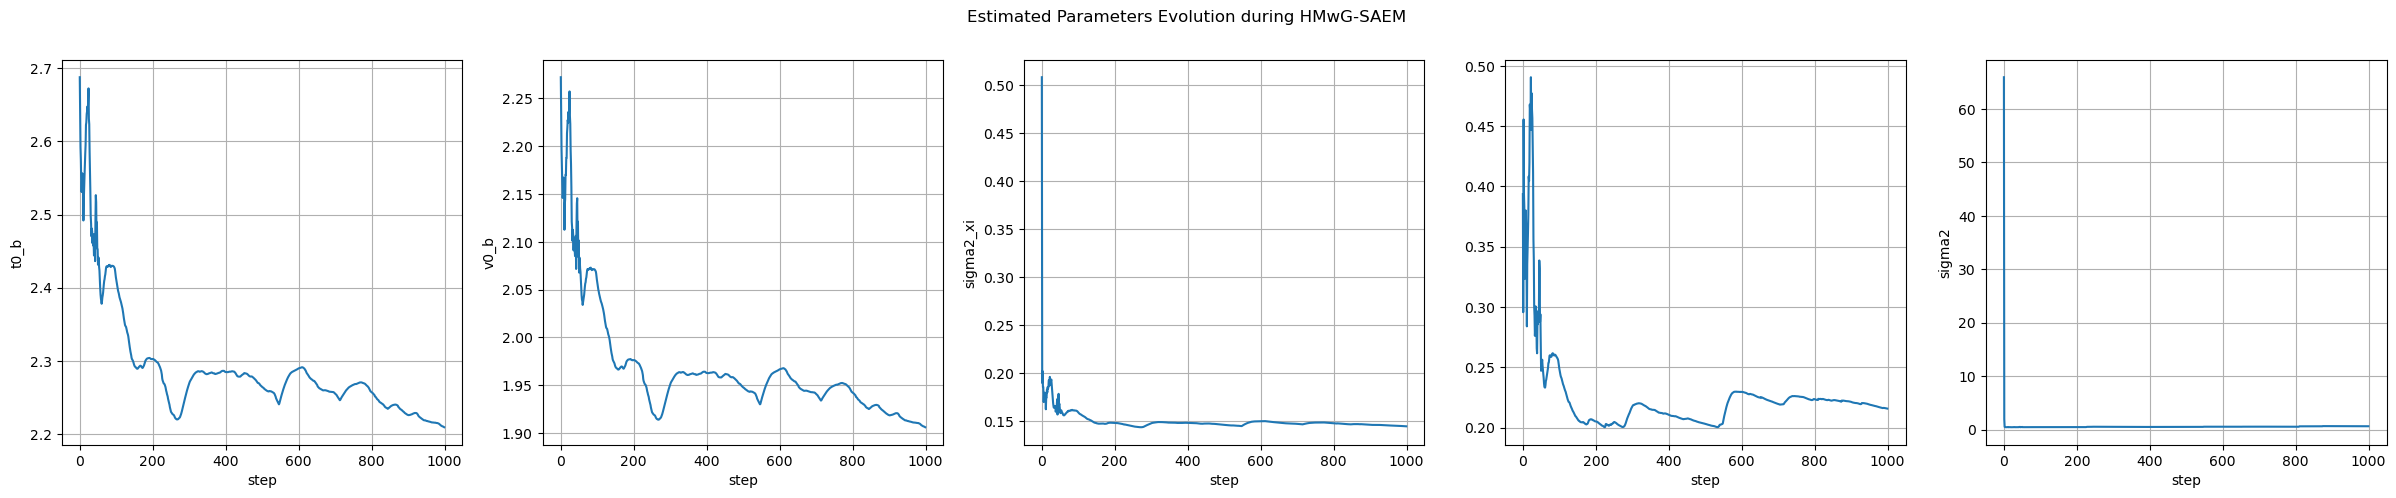

In [354]:
for k in theta_est: 
    print(f"########## {k} ########## \n")
    print(f"Estimated value : {theta_est[k]}")
    print(f"Ground truth : {parameters[k]}")
    print(f"Relative error : {jnp.abs(100*(theta_est[k]-parameters[k])/parameters[k]):.2f}% \n")

fig, ax = plt.subplots(1, 5, figsize = (30, 5))
ax[0].plot(param_ev["t0_b"])
ax[0].set_xlabel("step")
ax[0].set_ylabel("t0_b")
ax[0].grid()
ax[1].plot(param_ev["v0_b"])
ax[1].set_xlabel("step")
ax[1].set_ylabel("v0_b")
ax[1].grid()
ax[2].plot(param_ev["sigma2_xi"])
ax[2].set_xlabel("step")
ax[2].set_ylabel("sigma2_xi")
ax[2].grid()
ax[3].plot(param_ev["sigma2_tau"])
ax[3].set_xlabel("step")
ax[3].grid()
ax[4].plot(param_ev["sigma2"])
ax[4].set_xlabel("step")
ax[4].set_ylabel("sigma2")
ax[4].grid()

fig.suptitle("Estimated Parameters Evolution during HMwG-SAEM")
plt.show()

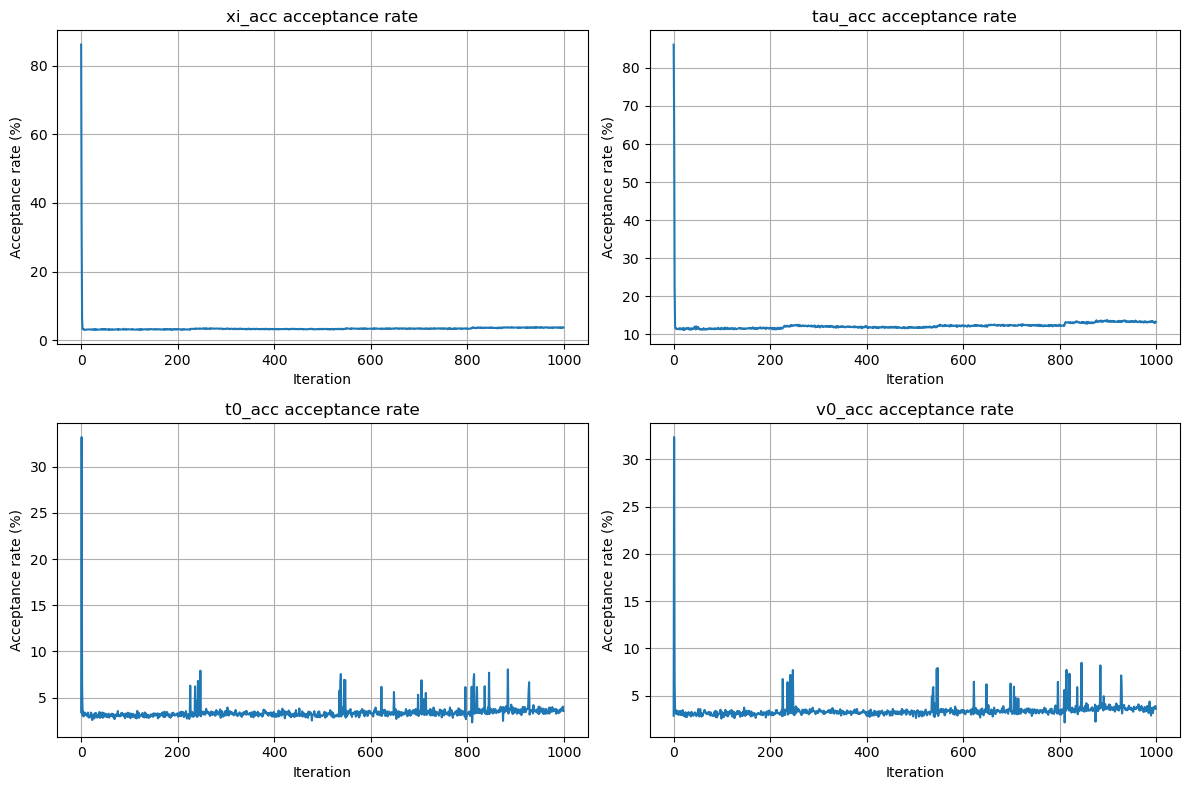

In [355]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
acc_keys = list(mean_acc.keys())
for idx, k in enumerate(acc_keys):
    row, col = divmod(idx, 2)
    acc_percent = 100 * mean_acc[k]
    ax[row, col].plot(acc_percent)
    ax[row, col].set_title(f'{k} acceptance rate')
    ax[row, col].set_xlabel('Iteration')
    ax[row, col].set_ylabel('Acceptance rate (%)')
    ax[row, col].grid()
plt.tight_layout()
plt.show()

>**Question 8 :** Générer les éléments par blocs plutôt que élément par élément permet de réduire le nombre d'appel à des échantillonneur métropolis hastings, et donc réduire le temps de calcul. Dans notre cas particulier où les $z_i$ et $z_{pop}$ sont des paires, on réduit par 2 notre temps de calcul.

>**Question 9 :** $\dots$

# **Exercice 2 :** 

>**Question 1 :** On note $(\mathcal{F_n})_{n\ge 0}$ la filtration canonique associée à $(X_n, Y_n)_{n \ge 0}$. D'après l'agorithme on a les lois conditionnelles suivantes : 
\begin{equation}
    X_n | \mathcal{F}_{n-1} \sim f_{X|Y}(\cdot, Y_{n-1}) \qquad Y_{n} | \mathcal{F}_{n-1},X_n \sim f_{Y|X}(X_n, \cdot)
\end{equation}
Pour une fonction teste $h$, on peut montrer que l'espérence conditionnelle $\mathbb{E}[h(X_n,Y_n)| \mathcal{F}_{n-1}]$ ne dépend que de $(X_{n-1}, Y_{n-1})$:
\begin{align}
    \mathbb{E}[h(X_n,Y_n)| \mathcal{F}_{n-1}] &=  \mathbb{E}\left[ \mathbb{E}[h(X_n,Y_n)|\mathcal{F_{n-1}},X_n ]| \mathcal{F_{n-1}}\right] \\
                                            &= \mathbb{E}\left[\int h(X_n, y)f_{Y|X}(X_n,y)dy | \mathcal{F_{n-1}}\right] \\
                                            &=  \int h(x, y)f_{Y|X}(X_n,y)f_{X|Y}(x, Y_{n-1})dydx
\end{align}
Ainsi $(X_n,Y_n)_{n \ge 0}$ forme bien une chaine de Markov dont le noyau de transition est donné par : 
\begin{equation}
P((x_0,y_0), dxdy) = f_{Y |X}(x,y)f_{X |Y}(x, y_0) dxdy
\end{equation}

>**Question 2 :** De même que pour la question précédente, en notant $(\mathcal{F}^Y_n)_{n \ge 0}$ la filtration canonique associée $(Y_n)_{n \ge 0}$, et en prenant $h$ une fonction teste, on montre que cette dernière est une chaine de Markov : 
\begin{align}
    \mathbb{E}[h(Y_n)| \mathcal{F}^Y_{n-1}] &= \mathbb{E}[\mathbb{E}[h(Y_n)|\mathcal{F}^Y_{n-1}, X_n]|\mathcal{F}^Y_{n-1}] \\
                                            &= \mathbb{E}\left[\int h(y)f_{Y|X}(X_n,y)dy|\mathcal{F}^Y_{n-1}\right] \\
                                            &= \int \int h(y)f_{Y|X}(x,y)f_{X|Y}(x,Y_{n-1})dxdy
\end{align}
Donc $(Y_n)_{n \ge 0}$ forme bien une chaine de Markov dont le noyau de transition est donné par : 
\begin{equation}
    P^Y(y_0, dy) = \left(\int f_{Y|X}(x,y)f_{X|Y}(x,y_0)dx\right)dy
\end{equation}
Montrons que $\pi^Y(dy) = f_Y(y)dy$ est invariante pour ce noyau de transition, plus préciement montrons l'équation de balance détaillée, pour $A$ et $B$ deux mesurables :
\begin{align}
    \int_{A\times B}P^Y(y_1, dy_2)\pi^Y(dy_1) &= \int_{A \times B}\int f_{Y|X}(x,y_2)f_{X|Y}(x,y_1)f_Y(y_1)dxdy_2dy_1 \\
                                            &= \int_{A \times B}\int \frac{f_{X|Y}(x,y_2)f_Y(y_2)}{f_X(x)}f(x,y_1)dxdy_2dy_1 \\
                                            &= \int_{A \times B}\int f_{X|Y}(x,y_2)f_{Y|X}(x,y_1)f_Y(y_2)dxdy_2{dy_1} \\
                                            &= \int_{A\times B}P^Y(y_2, dy_1)\pi^Y(dy_2)
\end{align} 
Cela permet de conclure quant au fait que $\pi^Y$ est invariante pour $P^Y$.

>**Question 3 :** Calculons les marginales de la densité jointe proposée : 
\begin{align}
    f_Y(y) &= \int_{-\infty}^{+\infty} f(x,y)dx \\ 
        &= \frac{4y^{\frac{3}{2}}}{\sqrt{2\pi}}e^{-2y}\int_{-\infty}^{+\infty}e^{-\frac{yx^2}{2}}dx1\!\!1_{\mathbb{R}_+}(y)\\
        &= 4 ye^{-2y}1\!\!1_{\mathbb{R}_+}(y)
\end{align}
et 
\begin{align}
    f_X(x) &= \int_{0}^{+\infty} f(x,y)dy \\
        &= \frac{4}{\sqrt{2\pi}(\frac{x^2}{2}+2)^{3/2}}\int_0^\infty \left(y(\frac{x^2}{2}+2)\right)^{3/2}e^{-y(\frac{x^2}{2}+2)}dy \\
        &= \frac{4}{\sqrt{2\pi}(\frac{x^2}{2}+2)^{5/2}}\Gamma\left(\frac{5}{2}\right) \\
        &= \frac{12}{(x^2+4)^{5/2}}
\end{align}
On peut déduire les densité conditionnelles : 
\begin{align}
    f_{X|Y}(x,y) &= \frac{f(x,y)}{f_Y(y)} \\
                &= \mathcal{N}\left(x\,\Big|\, 0, \frac{1}{y}\right)
\end{align}
et 
\begin{align}
    f_{Y|X}(x,y) &= \frac{f(x,y)}{f_X(x)} \\
                &= \frac{1}{3\sqrt{2\pi}}(x^2 +4)^{\frac{5}{2}}y^{\frac{3}{2}}\exp\left(-y\left(\frac{x^2}{2}+2\right)\right) \\
                &= \Gamma\left(y \,\Big|\, \frac{5}{2}, \left(\frac{x^2}{2}+2\right)\right)
\end{align}
Finalement un algorithme de Gibbs pour la densité jointe proposée consiste à alterner les étapes suivates : 
\begin{equation}
    \begin{cases}
        \text{Sample } X_n \sim \mathcal{N}(0, \frac{1}{Y_{n-1}}) \\
        \text{Sample } Y_n \sim \Gamma(\frac{5}{2}, (\frac{X_n^2}{2}+2)) \\
    \end{cases}
\end{equation}

In [356]:
def gibbs_sampler(key, y0, n_iter):
    
    def gibbs_step(y_prev, key):
        x = jnp.sqrt(1/y_prev)*jr.normal(key)
        y = jr.gamma(key, 5/2)/(x**2/2+2)
        return y, (x,y)
    
    keys = jr.split(key, n_iter)
    _, chain = jax.lax.scan(gibbs_step, y0, keys)
    return chain      

In [357]:
key, subkey = jr.split(key)
chain = gibbs_sampler(subkey, 1., 1000)

In [358]:
def joint_density(x, y):
    return 4 / (jnp.sqrt(2 * jnp.pi)) * (y ** (3 / 2)) * jnp.exp(-y * (x ** 2 / 2 + 2))

def density_x(x):
    return 12 / (x ** 2 + 4) ** (5 / 2)

def density_y(y):
    return 4 * y * jnp.exp(-2 * y)

def scatter_hist(x, y, ax, ax_histx, ax_histy):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histx.tick_params(axis="y", labelleft=False)
    ax_histy.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)

    # Create grid for contour plot
    x_line = jnp.linspace(-10, 10, 100)
    y_line = jnp.linspace(-1, 10, 100)
    X, Y = jnp.meshgrid(x_line, y_line)
    Z = joint_density(X, Y)
    log_Z = jnp.log(Z+10**(-5))

    # Contourf of the joint density
    ax.contourf(X, Y, log_Z, levels=20, cmap='viridis')

    # the scatter plot:
    ax.scatter(x, y, c="red", s=0.5)
   

    # Add histograms
    binwidth = 0.25
    xymax = max(jnp.max(jnp.abs(x)), jnp.max(jnp.abs(y)))
    lim = (int(xymax / binwidth) + 1) * binwidth
    bins = jnp.arange(-lim, lim + binwidth, binwidth)
    ax_histx.hist(x, bins=bins, density=True)
    ax_histy.hist(y, bins=bins, orientation='horizontal', density=True)

    # Add marginal density profile
    x_plot = jnp.linspace(-lim, lim, 500)
    ax_histx.plot(x_plot, density_x(x_plot), color='red', lw=2, label="$f_X(x)$")
    y_plot = jnp.linspace(-lim, lim, 500)
    y_plot_pos = y_plot[y_plot >= 0]
    ax_histy.plot(density_y(y_plot_pos), y_plot_pos, color='red', lw=2, label="$f_Y(y)$")


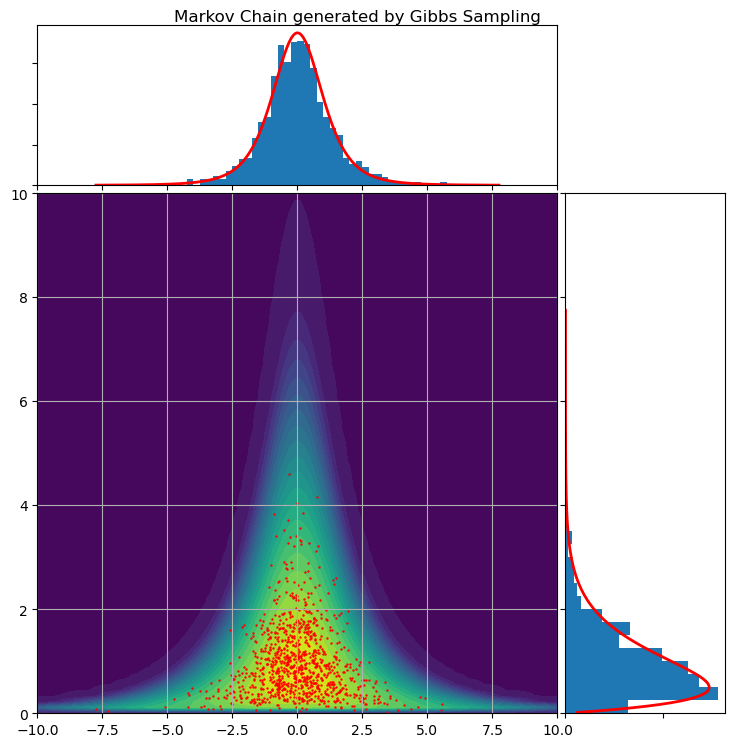

In [359]:

x, y = chain

left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.01

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]


scatter_xlim = (-10, 10)
scatter_ylim = (0, 10)

fig = plt.figure(figsize=(8, 8))

ax = fig.add_axes(rect_scatter)
ax_histx = fig.add_axes(rect_histx, sharex=ax)
ax_histy = fig.add_axes(rect_histy, sharey=ax)
ax.grid()

scatter_hist(x, y, ax, ax_histx, ax_histy)


ax.set_xlim(scatter_xlim)
ax.set_ylim(scatter_ylim)
fig.suptitle("Markov Chain generated by Gibbs Sampling")

plt.show()

>**Question 4 :** On remarque que, si $X \sim f_X$, on a :  
\begin{equation}
    \int_{\mathbb{R}} \frac{H(x)}{(x^2+4)^{\frac{5}{2}}}dx = \frac{1}{12} \mathbb{E}[H(X)]
\end{equation}
On commence par montrer, de même que dans les questions 1 et 2 que $(X_n)_{n\ge 0}$ est une chaine de Markov dont le noyau de transition est donné par : 
\begin{equation}
    P^X(x_0, dx) = \left(\int f_{X|Y}(x,y)f_{Y|X}(x_0,y)dy\right)dx
\end{equation}
Puis, de même qu'en question 2, on montre par l'equation de balance détaillée que $\pi^X(dx) = f(x)dx$ est une mesure invariante pour $P^X$. J'admets que cette chaine de Markov est ergodique, elle a donc pour distribution stationnaire $\pi^X$. Ainsi, une méthode pour approximer l'intégrale précédente est d'utiliser le théorème ergodique et la chaine de Markov générée par l'échantillonnage de Gibbs: 
\begin{equation}
    \lim_{n \to \infty} \frac{1}{n}\sum_{i = 1}^n H(X_n) = \mathbb{E}[H(X)]
\end{equation}

# **Exercice 3 :**